# Flow-matching guided evaluation

Interactive inspection of unconditional + guided generations from a trained `LitUncondFlowMatch` checkpoint.

References are **generated on the fly** via the same pipeline as
`scripts/flowmatch_guided/generate_si_training_dataset.py`, at one or more
crystalline fractions. No reference xyz file needed.

Requirements: `pip install py3Dmol ipywidgets`.

In [1]:
%load_ext autoreload
%autoreload 2

## CONFIG

In [2]:
CHECKPOINT = '/home/ehrdt/packages/tricor/scripts/flowmatch_guided/si/lightning_logs/flowmatch-uncond-si3n4/version_10/checkpoints/last.ckpt'

# Pure Si (single species). Override for multi-species checkpoints.
SPECIES = [14]
ATOM_FRACTIONS = [1.0]

# Generation cell = one TILE (must be cubic — the FM model produces cubic tiles).
# Tiled output cell = (nx, ny, nz) * CELL_SIZE. e.g. (1, 1, 4) -> 100 x 100 x 400.
CELL_SIZE = 100.0
NUM_ATOMS = None                 # None -> match the first generated reference (per tile)
TILES_PER_DIM = (1, 1, 4)        # (nx, ny, nz) tiles; (2,2,2)=200^3 cube, (1,1,4)=100x100x400

# --- reference generation (mirrors generate_si_training_dataset.py) ---
SI_LATTICE = 5.431
REFERENCE_CRYST_FRACS = [0.0, 0.1]   # one reference per entry; index 0 is the guidance target
REFERENCE_REL_DENSITY = 0.92
REFERENCE_NUM_STEPS = 200
REFERENCE_SEED = 7777                # distinct from training-set seeds (0..10)

# Spectra
R_MAX = 10.0
R_STEP = 0.05
PHI_NUM_BINS = 90
SIGMA_R = 0.15
SIGMA_PHI = 0.1
ADF_R_MAX = 3.5

# Sampling
CUTOFF = 5.0
UNCOND_STEPS = 50            # ODE steps per tile; 30-50 with midpoint is usually fine
GUIDED_STEPS = 0             # unused in tiling test (kept for downstream-cell compatibility)
T_SWITCH = 0.4
MIN_DIST_THRESHOLD = None
NOISE_SIGMA = 0.1
NOISE_SCHEDULE = 'linear'
W = 1.0
GUIDE_NORM_MODE = 'relative'
ADF_WEIGHT = 1.0
NUM_RUNS = 1                 # tiled structures to produce in this test

DEVICE = 'cuda'
SEED = 42

## Setup

In [3]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import ase.data
import ase.io
from ase.build import bulk

from tricor.shells import CoordinationShellTarget
from tricor.supercell import Supercell
from tricor.flowmatch.velocity_model_uncond import LitUncondFlowMatch
from tricor.flowmatch.sampler_guided import (
    generate_glass_style, positions_to_atoms,
)
from tricor.differentiable_pdf import DifferentiableSpectralLoss
from tricor.differentiable_pdf_fast import DifferentiablePDFADF_Fast as DifferentiablePDFADF

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device(DEVICE if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [4]:
def normalize_g2(g2_raw, r, num_center, num_neighbor, volume, dr):
    rho = num_neighbor / volume
    shell_vol = 4.0 * math.pi * r ** 2 * dr
    denom = num_center * rho * shell_vol
    return g2_raw / np.maximum(denom, 1e-12)

def normalize_adf(adf_raw, dphi):
    total = adf_raw.sum() * dphi
    return adf_raw / total if total > 1e-12 else adf_raw

def compute_normalized_spectra(atoms, calc, species_list):
    dev = calc.r_grid.device
    pos = torch.tensor(atoms.positions, dtype=torch.float64, device=dev)
    sp = torch.tensor(atoms.numbers, dtype=torch.long, device=dev)
    cell = torch.tensor(atoms.cell.array, dtype=torch.float64, device=dev)
    with torch.no_grad():
        g2_raw, adf_raw = calc.compute(pos, sp, cell)
    g2_raw = g2_raw.cpu().numpy(); adf_raw = adf_raw.cpu().numpy()
    r = calc.r_grid.cpu().numpy(); dr = float(calc.r_step)
    volume = abs(np.linalg.det(atoms.cell.array))
    ns = len(species_list)
    g2_norm = np.zeros_like(g2_raw)
    for i in range(ns):
        ni = (atoms.numbers == species_list[i]).sum()
        for j in range(ns):
            nj = (atoms.numbers == species_list[j]).sum()
            g2_norm[i, j] = normalize_g2(g2_raw[i, j], r, ni, nj, volume, dr)
    phi = calc.phi_grid.cpu().numpy()
    dphi = phi[1] - phi[0] if len(phi) > 1 else 1.0
    adf_norm = np.stack([normalize_adf(a, dphi) for a in adf_raw])
    return g2_norm, adf_norm

## Generate reference structures on the fly

Uses the same `Supercell.generate(...)` pipeline as `generate_si_training_dataset.py`.
Each entry in `REFERENCE_CRYST_FRACS` produces one reference. `REFERENCE_SEED` is offset
per-entry so they're all distinct (and different from the training seeds).

In [5]:
si_ref_crystal = bulk('Si', crystalstructure='diamond', a=SI_LATTICE, cubic=True)
shell_target = CoordinationShellTarget.from_atoms(si_ref_crystal)

# Uses the new Supercell.PRESETS (repulsion_weight / hard_core_scale /
# nonbond_push_scale / displacement_sigma) which enforce hard-sphere
# repulsion and produce faithful regime-specific structures.
#   0% cryst  -> 'amorphous'   preset (grain_size 4, fully amorphous Voronoi fill)
#   0.1-0.4   -> 'SRO'         preset (grain_size 8, short-range order)
#   0.4-0.7   -> 'MRO' / 'mixed' presets
#   >= 0.9    -> 'nanocrystalline'
# We override crystalline_fraction per entry so REFERENCE_CRYST_FRACS still drives it.

def preset_for_cf(cf: float) -> dict:
    if cf <= 0.0:
        return {**Supercell.PRESETS['amorphous'], 'grain_size': None, 'crystalline_fraction': 0.0}
    if cf < 0.4:
        return {**Supercell.PRESETS['SRO'], 'crystalline_fraction': cf}
    if cf < 0.7:
        return {**Supercell.PRESETS['MRO'], 'crystalline_fraction': cf}
    if cf < 0.95:
        return {**Supercell.PRESETS['mixed'], 'crystalline_fraction': cf}
    return {**Supercell.PRESETS['nanocrystalline'], 'crystalline_fraction': cf}

references = []  # list of (label, ase.Atoms)
for k, cf in enumerate(REFERENCE_CRYST_FRACS):
    seed_k = REFERENCE_SEED + k
    preset = preset_for_cf(cf)
    density = preset.pop('relative_density', REFERENCE_REL_DENSITY)
    num_steps = preset.pop('num_steps', REFERENCE_NUM_STEPS)
    sc = Supercell.from_atoms(
        si_ref_crystal, cell_dim_angstroms=CELL_SIZE,
        rng_seed=seed_k, relative_density=density,
    )
    sc.generate(shell_target, num_steps=num_steps, show_progress=False, **preset)
    label = f'ref {int(cf*100)}% cryst (seed={seed_k})'
    references.append((label, sc.atoms))
    print(f'{label}: {len(sc.atoms)} atoms, cell={sc.atoms.cell.lengths()}')


ref 0% cryst (seed=7777): 45945 atoms, cell=[100. 100. 100.]
ref 10% cryst (seed=7778): 45945 atoms, cell=[100. 100. 100.]


In [6]:
ref_label0, ref0 = references[0]
num_atoms = NUM_ATOMS if NUM_ATOMS is not None else len(ref0)   # per-TILE atom count
num_species = len(SPECIES)

calc = DifferentiablePDFADF(
    r_max=R_MAX, r_step=R_STEP, phi_num_bins=PHI_NUM_BINS,
    sigma_r=SIGMA_R, sigma_phi=SIGMA_PHI, species=SPECIES,
    adf_r_max=ADF_R_MAX,
    neighbor_chunk=256,              # lower for large (tiled) structures — ~2.3 GB peak at 368k atoms
    pair_chunk=200_000,
).double().to(device)

# Normalized spectra for every reference (for plotting comparisons)
ref_spectra = []
for label, atoms in references:
    g2n, adfn = compute_normalized_spectra(atoms, calc, SPECIES)
    ref_spectra.append((label, g2n, adfn))

# Per-reference RAW guidance targets (one per reference)
guidance_targets = []  # list of (label, target_g2, target_adf)
for label, atoms in references:
    rp = torch.tensor(atoms.positions, dtype=torch.float64, device=device)
    rs = torch.tensor(atoms.numbers, dtype=torch.long, device=device)
    rc = torch.tensor(atoms.cell.array, dtype=torch.float64, device=device)
    with torch.no_grad():
        tg2, tadf = calc.compute(rp, rs, rc)
    guidance_targets.append((label, tg2, tadf))
    print(f'guidance target ready: {label}')

loss_fn = DifferentiableSpectralLoss(calc, adf_weight=ADF_WEIGHT)

lit = LitUncondFlowMatch.load_from_checkpoint(CHECKPOINT, map_location=device)
lit.ema_model.to(device).eval()
print(f'Loaded: {CHECKPOINT}')

# --- species/composition setup FOR ONE TILE ---
fracs = np.array(ATOM_FRACTIONS); fracs = fracs / fracs.sum()
counts = np.round(fracs * num_atoms).astype(int)
counts[-1] = num_atoms - counts[:-1].sum()

species_list = []
z_rows = []
for i, (Z, c) in enumerate(zip(SPECIES, counts)):
    species_list.extend([Z] * c)
    onehot = torch.zeros(c, num_species); onehot[:, i] = 1.0
    z_rows.append(onehot)
species_t = torch.tensor(species_list, dtype=torch.long, device=device)
z = torch.cat(z_rows, dim=0).to(device)
cell_t = torch.diag(torch.tensor([CELL_SIZE] * 3, device=device))   # TILE cell

guidance target ready: ref 0% cryst (seed=7777)
guidance target ready: ref 10% cryst (seed=7778)
Loaded: /home/ehrdt/packages/tricor/scripts/flowmatch_guided/si/lightning_logs/flowmatch-uncond-si3n4/version_10/checkpoints/last.ckpt


## Generate (uncond + guided)

In [7]:
from tricor.flowmatch.sampler_guided import generate_unconditional
import ase as _ase

def tile_atoms(tiles, tile_grid):
    """Concatenate (nx, ny, nz) cubic Atoms into one rectangular cell.

    All tiles must share the same cubic edge length. Output cell is
    (nx*edge, ny*edge, nz*edge). Atom order: x-fastest, then y, then z.
    """
    nx, ny, nz = tile_grid
    total = nx * ny * nz
    assert len(tiles) == total, f'need {total} tiles, got {len(tiles)}'
    a = float(tiles[0].cell.array[0, 0])
    for t in tiles:
        diag = t.cell.array.diagonal()
        assert abs(diag[0] - a) < 1e-6 and abs(diag[1] - a) < 1e-6 and abs(diag[2] - a) < 1e-6, \
            'tiles must be cubic with matching edge'

    positions, numbers = [], []
    k = 0
    for iz in range(nz):
        for iy in range(ny):
            for ix in range(nx):
                shift = np.array([ix * a, iy * a, iz * a])
                positions.append(tiles[k].positions + shift)
                numbers.append(tiles[k].numbers)
                k += 1
    return _ase.Atoms(
        numbers=np.concatenate(numbers, axis=0),
        positions=np.concatenate(positions, axis=0),
        cell=[nx * a, ny * a, nz * a], pbc=True,
    )


uncond_atoms = []
uncond_g2s, uncond_adfs = [], []
guided_per_ref = [[] for _ in references]   # kept empty — downstream cells still iterate fine

nx, ny, nz = TILES_PER_DIM
n_per = nx * ny * nz
out_cell = (nx * CELL_SIZE, ny * CELL_SIZE, nz * CELL_SIZE)
for run in range(NUM_RUNS):
    print(f'\n=== tiled structure {run+1}/{NUM_RUNS} '
          f'({nx}x{ny}x{nz} = {n_per} tiles @ {CELL_SIZE}^3 Å '
          f'-> {out_cell[0]:.0f}x{out_cell[1]:.0f}x{out_cell[2]:.0f} Å) ===')
    tiles = []
    for t in range(n_per):
        torch.manual_seed(SEED + run * n_per + t + 1)
        pos = generate_unconditional(
            cell_t, num_atoms, z, lit.ema_model,
            cutoff=CUTOFF, num_steps=UNCOND_STEPS, method='midpoint',
        )
        tiles.append(positions_to_atoms(pos, cell_t, species_t))
        print(f'  tile {t+1}/{n_per} done')

    big = tile_atoms(tiles, TILES_PER_DIM)
    print(f'  assembled: {len(big)} atoms in {big.cell.lengths()} Å cell')
    g2u, adfu = compute_normalized_spectra(big, calc, SPECIES)
    uncond_atoms.append(big)
    uncond_g2s.append(g2u)
    uncond_adfs.append(adfu)

print('\nDone.')


=== tiled structure 1/1 (1x1x4 = 4 tiles @ 100.0^3 Å -> 100x100x400 Å) ===
  tile 1/4 done
  tile 2/4 done
  tile 3/4 done
  tile 4/4 done
  assembled: 183780 atoms in [100. 100. 400.] Å cell

Done.


## g(r) — per species pair, one panel row per reference

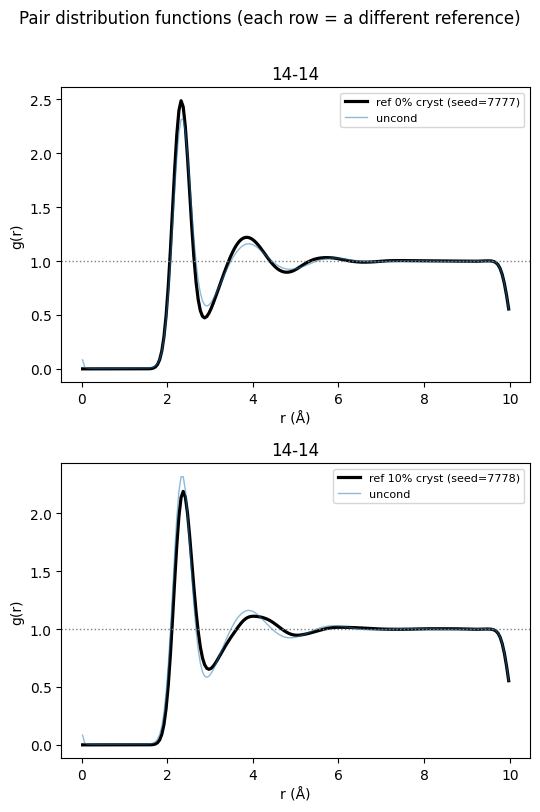

In [8]:
r = calc.r_grid.cpu().numpy()
phi_deg = np.rad2deg(calc.phi_grid.cpu().numpy())
pair_labels = calc.pair_labels
triplet_labels = calc.triplet_labels

ref_g2_0 = ref_spectra[0][1]
ref_adf_0 = ref_spectra[0][2]
num_pairs = ref_g2_0.shape[0] * ref_g2_0.shape[1]
num_triplets = ref_adf_0.shape[0]

nrows = len(ref_spectra)
fig, axs = plt.subplots(nrows, num_pairs,
                         figsize=(5.5 * num_pairs, 4.0 * nrows),
                         squeeze=False)
for row, (label, rg2, _) in enumerate(ref_spectra):
    guided_g2s_row = [g for _, g, _ in guided_per_ref[row]]
    idx = 0
    for i in range(rg2.shape[0]):
        for j in range(rg2.shape[1]):
            ax = axs[row][idx]
            ax.plot(r, rg2[i, j], 'k-', lw=2.3, label=label)
            for k, g in enumerate(uncond_g2s):
                ax.plot(r, g[i, j], color='tab:blue', lw=1.0, alpha=0.5,
                        label='uncond' if k == 0 else None)
            for k, g in enumerate(guided_g2s_row):
                ax.plot(r, g[i, j], color='tab:red', lw=1.3, alpha=0.75,
                        label=f'guided->{label[:14]}' if k == 0 else None)
            ax.axhline(1.0, color='gray', ls=':', lw=1)
            ax.set_xlabel('r (Å)'); ax.set_ylabel('g(r)')
            ax.set_title(f'{pair_labels[idx]}'); ax.legend(fontsize=8)
            idx += 1
fig.suptitle('Pair distribution functions (each row = a different reference)', y=1.01)
plt.tight_layout(); plt.show()


## ADF — per triplet, one row per reference

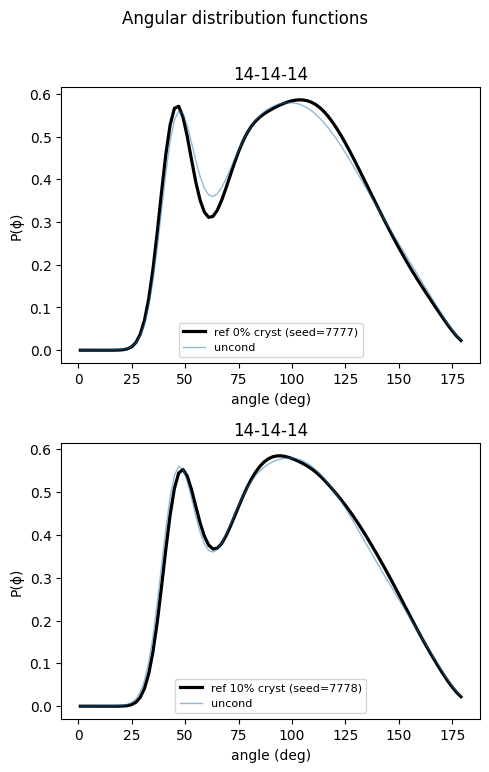

In [9]:
ncols = min(num_triplets, 3)
trip_rows_per_ref = (num_triplets + ncols - 1) // ncols
total_rows = trip_rows_per_ref * len(ref_spectra)

fig, axs = plt.subplots(total_rows, ncols,
                         figsize=(5 * ncols, 3.8 * total_rows),
                         squeeze=False)
for ref_idx, (label, _, radf) in enumerate(ref_spectra):
    base = ref_idx * trip_rows_per_ref
    guided_adfs_row = [a for _, _, a in guided_per_ref[ref_idx]]
    for t in range(num_triplets):
        ax = axs[base + t // ncols][t % ncols]
        ax.plot(phi_deg, radf[t], 'k-', lw=2.3, label=label)
        for k, a in enumerate(uncond_adfs):
            ax.plot(phi_deg, a[t], color='tab:blue', lw=1.0, alpha=0.5,
                    label='uncond' if k == 0 else None)
        for k, a in enumerate(guided_adfs_row):
            ax.plot(phi_deg, a[t], color='tab:red', lw=1.3, alpha=0.75,
                    label=f'guided->{label[:14]}' if k == 0 else None)
        ax.set_xlabel('angle (deg)'); ax.set_ylabel('P(ϕ)')
        ax.set_title(triplet_labels[t]); ax.legend(fontsize=8)
    for t in range(num_triplets, trip_rows_per_ref * ncols):
        axs[base + t // ncols][t % ncols].set_visible(False)
fig.suptitle('Angular distribution functions', y=1.01)
plt.tight_layout(); plt.show()


## Interactive 3D viewer

Includes every reference plus all generated uncond/guided samples.

In [10]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from ase.neighborlist import neighbor_list

TETRAHEDRAL_THRESH = 0.4   # max mean-NN-displacement norm to classify as crystalline
COLORMAP = 'Reds'          # colormap for crystalline bonds (depth-shaded)
ELEVATION = 15.0
AZIMUTH = 45.0
FIG_SIZE = 7


def classify_crystalline(atoms, shell_target, bond_cutoff=None, thresh=TETRAHEDRAL_THRESH):
    """Classify atoms as crystalline using the same logic as Supercell.plot_structure.

    An atom is crystalline if it has K (coordination target) nearest neighbors
    within bond_cutoff AND the mean displacement of those neighbors is below
    thresh (i.e. symmetric / tetrahedral coordination).
    """
    cell_mat = np.asarray(atoms.cell.array, dtype=np.float64)
    cell_inv = np.linalg.inv(cell_mat)
    pos = atoms.positions.copy()
    n = len(atoms)

    if bond_cutoff is None:
        if shell_target is not None:
            pair_peak_max = float(np.max(np.asarray(shell_target.pair_peak, dtype=np.float64)))
            bond_cutoff = pair_peak_max * 1.2
        else:
            bond_cutoff = 3.0

    if shell_target is not None:
        coord_target = np.asarray(shell_target.coordination_target, dtype=np.float64)
        unique_species = np.array(shell_target.species, dtype=np.int64)
        species_idx = np.searchsorted(unique_species, atoms.numbers)
        k_per_atom = np.array([int(np.round(coord_target[species_idx[a]].sum())) for a in range(n)])
    else:
        k_per_atom = np.full(n, 4)

    bi, bj, bd = neighbor_list('ijd', atoms, bond_cutoff)

    is_cryst = np.zeros(n, dtype=bool)
    for a in range(n):
        mask = bi == a
        nn_count = int(np.sum(mask))
        k = int(k_per_atom[a])
        if nn_count < max(k - 1, 1) or nn_count > k + 1:
            continue
        dists_a = bd[mask]
        js_a = bj[mask]
        order = np.argsort(dists_a)[:k]
        delta = pos[js_a[order]] - pos[a]
        frac = delta @ cell_inv
        frac -= np.rint(frac)
        dxyz = frac @ cell_mat
        mean_disp = np.linalg.norm(np.mean(dxyz, axis=0))
        if mean_disp < thresh:
            is_cryst[a] = True

    return is_cryst, bond_cutoff


def plot_structure_standalone(atoms, shell_target, theta_deg=AZIMUTH, figsize=FIG_SIZE):
    """Render structure with crystalline bonds as thick red lines (like plot_structure)."""
    cell_mat = np.asarray(atoms.cell.array, dtype=np.float64)
    cell_inv = np.linalg.inv(cell_mat)
    pos = atoms.positions.copy()

    is_cryst, bond_cutoff = classify_crystalline(atoms, shell_target)
    n_cryst = int(is_cryst.sum())
    cryst_frac = n_cryst / len(atoms)

    bi_all, bj_all, _ = neighbor_list('ijd', atoms, bond_cutoff)
    mask_ij = bi_all < bj_all
    bi, bj = bi_all[mask_ij], bj_all[mask_ij]

    bond_is_cryst = is_cryst[bi] & is_cryst[bj]

    # Min-image bond vectors
    delta = pos[bj] - pos[bi]
    frac = delta @ cell_inv
    frac -= np.rint(frac)
    bond_vecs = frac @ cell_mat
    bstart = pos[bi]
    bend = bstart + bond_vecs

    # Center
    a_vec, b_vec, c_vec = cell_mat[0], cell_mat[1], cell_mat[2]
    center = 0.5 * (a_vec + b_vec + c_vec)
    pos_c = pos - center
    bstart_c = bstart - center
    bend_c = bend - center

    # Cell outline
    o = -center
    corners = [o, o+a_vec, o+b_vec, o+c_vec,
               o+a_vec+b_vec, o+a_vec+c_vec, o+b_vec+c_vec,
               o+a_vec+b_vec+c_vec]
    edge_pairs = [(0,1),(0,2),(0,3),(1,4),(1,5),(2,4),(2,6),(3,5),(3,6),(4,7),(5,7),(6,7)]
    cell_segs = [(corners[i], corners[j]) for i, j in edge_pairs]

    cmap = plt.get_cmap(COLORMAP)
    extent = float(np.max(np.abs(pos_c))) * 1.15
    theta = np.deg2rad(theta_deg)

    def rot2d(pts, th):
        c_, s_ = np.cos(th), np.sin(th)
        out = pts.copy()
        out[:, 0] = pts[:, 0] * c_ - pts[:, 1] * s_
        out[:, 1] = pts[:, 0] * s_ + pts[:, 1] * c_
        return out

    bs_r = rot2d(bstart_c, theta)
    be_r = rot2d(bend_c, theta)

    fig = plt.figure(figsize=(figsize, figsize))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    try:
        ax.set_proj_type('persp', focal_length=0.25)
    except (TypeError, AttributeError):
        pass

    # Amorphous bonds: very faint
    bnd_mask = ~bond_is_cryst
    if np.any(bnd_mask):
        segs_b = list(zip(bs_r[bnd_mask], be_r[bnd_mask]))
        lc_b = Line3DCollection(segs_b, linewidths=0.3, colors=(0,0,0,0.05))
        ax.add_collection3d(lc_b)

    # Crystalline bonds: thick, depth-coloured
    cryst_mask = bond_is_cryst
    if np.any(cryst_mask):
        segs_cr = list(zip(bs_r[cryst_mask], be_r[cryst_mask]))
        mid_x = 0.5 * (bs_r[cryst_mask, 0] + be_r[cryst_mask, 0])
        norm_depth = np.clip((mid_x + extent) / max(2.0 * extent, 1e-12), 0, 1)
        cryst_colors = cmap(0.15 + 0.8 * norm_depth)
        cryst_lw = 0.4 + 1.6 * norm_depth
        lc_c = Line3DCollection(segs_cr, linewidths=cryst_lw, colors=cryst_colors)
        ax.add_collection3d(lc_c)

    # Cell outline
    cell_segs_r = []
    for s, e in cell_segs:
        s_r = rot2d(s.reshape(1,3), theta)[0]
        e_r = rot2d(e.reshape(1,3), theta)[0]
        cell_segs_r.append((s_r, e_r))
    lc_cell = Line3DCollection(cell_segs_r, linewidths=1.5, colors='k', alpha=0.5)
    ax.add_collection3d(lc_cell)

    # Atoms: tiny dots
    pos_r = rot2d(pos_c, theta)
    ax.scatter(pos_r[:,0], pos_r[:,1], pos_r[:,2], s=10, c='k', alpha=0.15,
               edgecolors='none', depthshade=False)

    ax.set_xlim(-extent, extent)
    ax.set_ylim(-extent, extent)
    ax.set_zlim(-extent, extent)
    ax.set_box_aspect([1,1,1])
    ax.view_init(elev=ELEVATION, azim=0)
    ax.axis('off')
    fig.subplots_adjust(left=-0.05, right=1.05, bottom=-0.05, top=1.05)
    return fig, n_cryst, cryst_frac


# --- Dropdown viewer ---
catalog = []
for label, atoms in references:
    catalog.append((label, atoms))
for i, a in enumerate(uncond_atoms):
    catalog.append((f'uncond #{i}', a))
for ref_idx, (ref_label, _) in enumerate(references):
    for i, (a, _, _) in enumerate(guided_per_ref[ref_idx]):
        catalog.append((f'guided->{ref_label} #{i}', a))
labels_list = [c[0] for c in catalog]

dd = widgets.Dropdown(options=list(zip(labels_list, range(len(catalog)))),
                      value=0, description='Structure:')
angle = widgets.FloatSlider(value=45, min=0, max=360, step=5, description='Rotation:')
out = widgets.Output()

def _show(change=None):
    out.clear_output(wait=True)
    label, atoms = catalog[dd.value]
    with out:
        fig, nc, cf = plot_structure_standalone(atoms, shell_target, theta_deg=angle.value)
        plt.title(f'{label}  |  {len(atoms)} atoms  |  cryst: {nc} ({cf:.1%})', fontsize=11)
        plt.show()

dd.observe(_show, names='value')
angle.observe(_show, names='value')
display(widgets.HBox([dd, angle]), out); _show()


Output()

## Per-structure RMSE table (vs every reference)

In [11]:
from pathlib import Path
from ase.io import write as ase_write

SAVE_DIR = './eval_structures/'
save_dir = Path(SAVE_DIR)
save_dir.mkdir(parents=True, exist_ok=True)

# References
for label, atoms in references:
    tag = label.replace(' ', '_').replace('(', '').replace(')', '').replace('%', 'pct')
    ase_write(str(save_dir / f'{tag}.xyz'), atoms)

# Uncond
for i, a in enumerate(uncond_atoms):
    ase_write(str(save_dir / f'uncond_{i:02d}.xyz'), a)

# Guided (per reference target)
for ref_idx, (ref_label, _) in enumerate(references):
    tag = ref_label.replace(' ', '_').replace('(', '').replace(')', '').replace('%', 'pct')
    for i, (a, _, _) in enumerate(guided_per_ref[ref_idx]):
        ase_write(str(save_dir / f'guided_to_{tag}_{i:02d}.xyz'), a)

print(f'Saved all structures to {save_dir}')
!ls -la {SAVE_DIR}


Saved all structures to eval_structures
total 14548
drwxrwxr-x 2 ehrdt ehrdt    4096 Apr 23 18:15  .
drwxrwxr-x 3 ehrdt ehrdt    4096 Apr 23 18:15  ..
-rw-rw-r-- 1 ehrdt ehrdt 2481202 Apr 23 18:15 'ref_0pct_cryst_seed=7777.xyz'
-rw-rw-r-- 1 ehrdt ehrdt 2481288 Apr 23 18:15 'ref_10pct_cryst_seed=7778.xyz'
-rw-rw-r-- 1 ehrdt ehrdt 9924222 Apr 23 18:15  uncond_00.xyz


In [12]:
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))

print(f"{'kind':<22} {'idx':>4}" + ''.join(f'  {"g(r)@"+lab[:16]:>22}  {"ADF@"+lab[:16]:>22}' for lab,*_ in ref_spectra))

def _row(kind, idx, g, a):
    return f'{kind:<22} {idx:>4}' + ''.join(f'  {rmse(g, rg):>22.4f}  {rmse(a, ra):>22.4f}' for _, rg, ra in ref_spectra)

for i, (g, a) in enumerate(zip(uncond_g2s, uncond_adfs)):
    print(_row('uncond', i, g, a))
for ref_idx, (ref_label, _) in enumerate(references):
    for i, (_, g, a) in enumerate(guided_per_ref[ref_idx]):
        print(_row(f'guided->{ref_label[:14]}', i, g, a))


kind                    idx   g(r)@ref 0% cryst (se    ADF@ref 0% cryst (se   g(r)@ref 10% cryst (s    ADF@ref 10% cryst (s
uncond                    0                  0.0503                  0.0201                  0.0562                  0.0145
